# DDSP Timbre Transfer (Local)

This notebook loads a local DDSP checkpoint and resynthesizes audio using extracted f0 and loudness features.

Requirements: `ddsp`, `librosa`, `soundfile`, `tensorflow`, and `gin`.

In [1]:
import glob
import os
import time

import gin
import librosa
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import tensorflow.compat.v2 as tf

import ddsp
import ddsp.training
import sys
from pathlib import Path


# Add src to path to import baseline
PROJECT_ROOT = Path.cwd().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
from src.analysis.visualize import plot_spectrograms,plot_features
from src.utils.model_loading import find_model_dir, find_latest_checkpoint
from src.utils.timbre_transfer_utils import (
    auto_adjust_features,
    compute_features,
    load_dataset_stats,
    shift_f0,
    shift_loudness,
    trim_features,
)
from timbre_transfer import load_model, resynthesize

DEFAULT_SAMPLE_RATE = 16000




2026-03-03 02:39:35.175237: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-03 02:39:35.407615: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-03 02:39:36.500084: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda-11.8/lib64:/usr/local/cuda-11.2/lib64:
2026-03-03 02:39:36.500420: W tensorflow/co

In [2]:
# Paths and parameters
project_root = '../../'
model_dir = project_root + 'artifacts/trained_noreverb/'
input_audio_dir =  project_root +'data/raw/voice/forte/'
output_audio_dir =  project_root + 'artifacts/voice-violin_transfer/'

sample_rate = DEFAULT_SAMPLE_RATE

pitch_shift = 0.0
loudness_shift = 0.0
auto_adjust = False
threshold = 1.0
quiet = 20.0
autotune = 0.0


In [3]:
# Load audio files and compute features
audio_items = []
wav_files = sorted(
    f for f in os.listdir(input_audio_dir) if f.endswith(".wav")
)
for file in wav_files:
    input_audio = os.path.join(input_audio_dir, file)
    output_audio = os.path.join(
        output_audio_dir, file.replace(".wav", "_TRANSFERED.wav")
)
    audio, _ = librosa.load(input_audio, sr=sample_rate, mono=True)
    audio = audio[np.newaxis, :]
    audio_features = compute_features(audio)
    audio_items.append(
        {
            "input_path": input_audio,
            "output_path": output_audio,
            "audio": audio,
            "features": audio_features,
        }
    )

if not audio_items:
    raise ValueError(f"No .wav files found in {input_audio_dir}")

2026-03-03 02:39:42.212207: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-03 02:39:42.351615: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-03 02:39:42.351672: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-03 02:39:42.353302: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other ope

In [4]:
# Load model, adjust features, resynthesize
model_dir = find_model_dir(model_dir)
gin_file = os.path.join(model_dir, 'operative_config-0.gin')
if not tf.io.gfile.exists(gin_file):
    gin_candidates = glob.glob(os.path.join(model_dir, '*.gin'))
    if not gin_candidates:
        raise FileNotFoundError('No gin file found in model_dir')
    gin_file = gin_candidates[0]

dataset_stats = load_dataset_stats(model_dir)

# Initialize model using the first sample's shape
init_audio = audio_items[0]["audio"]
init_features = audio_items[0]["features"]
model, _ = load_model(model_dir, gin_file, init_audio, init_features)

demo_audio = None
demo_audio_gen = None

for idx, item in enumerate(audio_items):
    audio = item["audio"]
    audio_features = item["features"]

    if auto_adjust and dataset_stats is not None:
        audio_features = auto_adjust_features(
            audio_features,
            dataset_stats,
            threshold=threshold,
            quiet=quiet,
            autotune_amount=autotune,
        )
    audio_features = shift_loudness(audio_features, loudness_shift)
    audio_features = shift_f0(audio_features, pitch_shift)

    audio_gen = resynthesize(model, audio_features)

    os.makedirs(os.path.dirname(item["output_path"]), exist_ok=True)
    sf.write(item["output_path"], audio_gen, sample_rate)
    print(f"Wrote {item['output_path']}")

    if idx == 0:
        demo_audio = audio
        demo_audio_gen = audio_gen

# Keep the first sample for display
audio = demo_audio
audio_gen = demo_audio_gen

/home/namkhanh/miniconda3/envs/conda_env3.10/lib/python3.10/site-packages/librosa/core/convert.py:1869: RuntimeWarning: divide by zero encountered in log10
  + 2 * np.log10(f_sq)


Restoring model took 0.8 seconds
Prediction took 0.2 seconds
Wrote ../../artifacts/voice-violin_transfer/f1_long_forte_a_TRANSFERED.wav
Prediction took 0.2 seconds
Wrote ../../artifacts/voice-violin_transfer/f1_long_forte_e_TRANSFERED.wav
Prediction took 0.1 seconds
Wrote ../../artifacts/voice-violin_transfer/f1_long_forte_i_TRANSFERED.wav
Prediction took 0.1 seconds
Wrote ../../artifacts/voice-violin_transfer/f1_long_forte_o_TRANSFERED.wav
Prediction took 0.1 seconds
Wrote ../../artifacts/voice-violin_transfer/f1_long_forte_u_TRANSFERED.wav


In [5]:
# Listen back (first sample only)
from IPython.display import Audio, display
display(Audio(audio[0], rate=sample_rate))
display(Audio(audio_gen, rate=sample_rate))

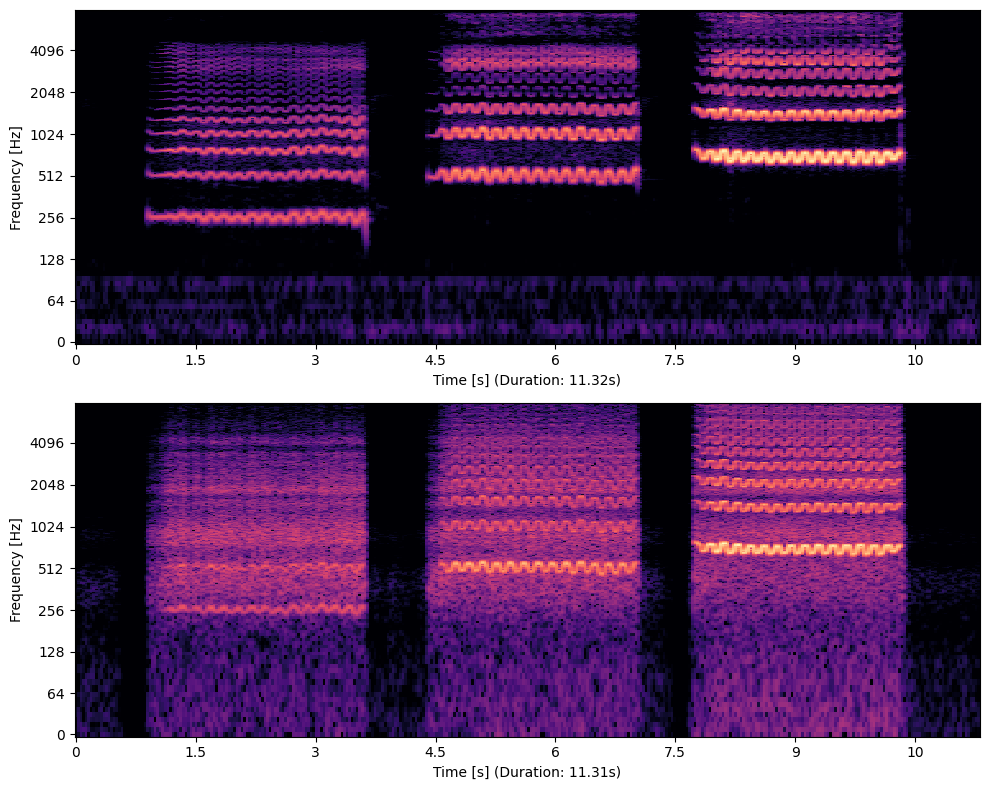

In [6]:
# Spectrograms (first sample only)
plot_spectrograms([audio[0], audio_gen], sample_rate)